# PoC 1: Seizure/Ictal Classifier

**Goal:** Can we beat the threshold-based seizure detector using a
supervised model trained directly on LFP windows?

**Data source:** Behavioral seizure labels from the BHZ analysis pipeline
(CSV export from `behavioral_seizure_detector.m`), with .mat files on E: drive (ED106).
These labels contain Peak_Index (sample index of seizure peak) for each detected event.

**Data flow:**
1. Load labelled seizure events from external CSV (behavioral seizure analysis).
2. Remap file paths from original G: drive to E: drive.
3. Extract 2-second LFP windows centred on each event peak (positives) and random
   non-overlapping windows from the same files (negatives).
4. Compute STFT spectrograms and Welch band powers.
5. Train/evaluate Logistic Regression and a small CNN.
6. Compare F1 scores and issue a go/no-go verdict.

In [1]:
import sys, os

# Ensure project root is importable
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import stft, iirnotch, filtfilt, butter, welch
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

from _common import load_lfp_window, load_mat

plt.style.use('dark_background')

# ---- Paths ----
SEIZURE_CSV = r'D:\code\analysis-behavioral-seizure-scoring\BHZ\BehaviorAnalysis__CH_1_3__2025_03_05__12_12.csv'
# Remap original drive paths to current E: drive location
PATH_REMAPS = {
    'G:\\Baseline_BCH039_BCH040\\': 'E:/20250302_Baseline_BCH039-NULL-BCH040-BCH040/',
}

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Seizure CSV: {SEIZURE_CSV}')
print(f'PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}')

Seizure CSV: D:\code\analysis-behavioral-seizure-scoring\BHZ\BehaviorAnalysis__CH_1_3__2025_03_05__12_12.csv
PyTorch: 2.11.0+cpu  CUDA: False


## 1. Load seizure labels from behavioral analysis CSV

In [2]:
# Load behavioral seizure analysis CSV
raw_df = pd.read_csv(SEIZURE_CSV)
assert len(raw_df) > 0, f'CSV is empty: {SEIZURE_CSV}'

# Keep only rows with actual detected events (non-NaN Peak_Index)
events_df = raw_df[raw_df['Peak_Index'].notna()].copy()
assert len(events_df) > 0, 'No seizure events with valid Peak_Index found'

# Remap folder paths to current E: drive
def remap_path(folder, filename):
    """Remap original drive paths to accessible E: drive location."""
    folder = str(folder)
    for old, new in PATH_REMAPS.items():
        folder = folder.replace(old, new)
    folder = folder.replace(chr(92), '/')
    return folder + filename

events_df['file_path'] = events_df.apply(
    lambda r: remap_path(r['folder'], r['filename']), axis=1
)

# Extract session name from folder (last directory component)
events_df['session_dir'] = events_df['folder'].apply(
    lambda f: str(f).replace(chr(92), '/').rstrip('/').rsplit('/', 1)[-1]
)

# Compute onset_sec from Peak_Index and sampling rate
events_df['onset_sec'] = events_df['Peak_Index'] / events_df['fs']

# Use Peak_Start/Peak_Stop for offset if available, else onset + 2s
events_df['offset_sec'] = events_df.apply(
    lambda r: r['Peak_Stop'] / r['fs'] if pd.notna(r['Peak_Stop']) and r['Peak_Stop'] > 0
    else r['onset_sec'] + 2.0, axis=1
)

# Verify files are accessible
events_df['file_exists'] = events_df['file_path'].apply(os.path.isfile)
n_accessible = events_df['file_exists'].sum()
print(f'Total seizure events : {len(events_df):,}')
print(f'Files accessible     : {n_accessible}/{len(events_df)}')
print(f'Unique files         : {events_df["filename"].nunique():,}')
print(f'Unique sessions      : {events_df["session_dir"].nunique():,}')
print(f'Date range           : {events_df["Peak_Date"].min()} to {events_df["Peak_Date"].max()}')
print(f'Sampling rate        : {events_df["fs"].unique()}')
print(f'Channel(s)           : {events_df["Channel"].unique()}')
print()

# Drop inaccessible files
events_df = events_df[events_df['file_exists']].copy()
assert len(events_df) > 0, 'No accessible seizure event files found'
print(f'Events with accessible files: {len(events_df)}')

Total seizure events : 72
Files accessible     : 72/72
Unique files         : 63
Unique sessions      : 2
Date range           : 2025-02-10 to 2025-03-04
Sampling rate        : [5000]
Channel(s)           : [1 3]

Events with accessible files: 72


## 2. Extract labeled windows

In [3]:
WINDOW_SEC = 2.0        # window duration
NEG_POS_RATIO = 3       # negative-to-positive ratio
MAX_EVENTS = 50000      # hard cap on events processed


def apply_filters(signal, fs):
    """Apply 60 Hz notch and 0.5-200 Hz bandpass filter."""
    assert signal.ndim == 1, f'Expected 1D signal, got shape {signal.shape}'
    assert fs > 0, f'Invalid sampling rate: {fs}'

    # 60 Hz notch
    b_notch, a_notch = iirnotch(60.0, Q=30.0, fs=fs)
    signal = filtfilt(b_notch, a_notch, signal)

    # Bandpass 0.5 -- 200 Hz
    nyq = fs / 2.0
    low = 0.5 / nyq
    high = min(200.0 / nyq, 0.99)
    b_bp, a_bp = butter(4, [low, high], btype='band')
    signal = filtfilt(b_bp, a_bp, signal)

    return signal


def sample_negative_windows(file_dur, seizure_intervals, n_neg, window_sec, rng):
    """Sample random non-overlapping windows outside seizure intervals."""
    assert n_neg >= 0, f'n_neg must be >= 0, got {n_neg}'
    assert window_sec > 0, f'window_sec must be > 0, got {window_sec}'

    negatives = []
    max_attempts = n_neg * 10
    for attempt in range(max_attempts):
        if len(negatives) >= n_neg:
            break
        start = rng.uniform(0, max(0, file_dur - window_sec))
        end = start + window_sec
        overlap = False
        for s_on, s_off in seizure_intervals:
            if start < s_off and end > s_on:
                overlap = True
                break
        if not overlap:
            negatives.append((start, end))
    return negatives


# ---- Main extraction loop ----
rng = np.random.RandomState(SEED)
windows = []   # list of (signal_1d, label, session_dir, file_path)
skipped = 0
actual_fs = None  # will be set from first loaded file

grouped = events_df.groupby('file_path')
n_files = min(len(grouped), MAX_EVENTS)

for file_path, group in tqdm(grouped, total=n_files, desc='Extracting windows'):
    row0 = group.iloc[0]
    session_dir = row0['session_dir']
    # CSV Channel is 1-based; load_lfp_window uses 0-based
    channel = int(row0['Channel']) - 1

    # Load the full file to get duration and true fs
    try:
        chunk = load_mat(file_path)
        file_dur = chunk.duration_sec
        fs = chunk.fs
        if actual_fs is None:
            actual_fs = fs
        del chunk  # free memory
    except Exception as exc:
        skipped += len(group)
        if skipped <= 5:
            print(f'  [skip] cannot load {os.path.basename(file_path)}: {exc}')
        continue

    # Collect seizure intervals
    seizure_intervals = []
    for _, ev in group.iterrows():
        seizure_intervals.append((ev['onset_sec'], ev['offset_sec']))

    # --- Positive windows ---
    for _, ev in group.iterrows():
        center = ev['onset_sec']
        start = max(0, center - WINDOW_SEC / 2)
        end = start + WINDOW_SEC
        try:
            sig, fs_out = load_lfp_window(file_path, start, end,
                                          channels=[channel])
            sig_1d = sig[:, 0].astype(np.float64)
            if len(sig_1d) < int(0.5 * WINDOW_SEC * fs_out):
                skipped += 1
                continue
            sig_1d = apply_filters(sig_1d, fs_out)
            windows.append((sig_1d, 1, session_dir, file_path))
        except Exception as exc:
            skipped += 1
            if skipped <= 5:
                print(f'  [skip] onset={center:.1f}s: {exc}')

    # --- Negative windows ---
    n_neg = len(group) * NEG_POS_RATIO
    neg_intervals = sample_negative_windows(
        file_dur, seizure_intervals, n_neg, WINDOW_SEC, rng
    )
    for start, end in neg_intervals:
        try:
            sig, fs_out = load_lfp_window(file_path, start, end,
                                          channels=[channel])
            sig_1d = sig[:, 0].astype(np.float64)
            if len(sig_1d) < int(0.5 * WINDOW_SEC * fs_out):
                skipped += 1
                continue
            sig_1d = apply_filters(sig_1d, fs_out)
            windows.append((sig_1d, 0, session_dir, file_path))
        except Exception as exc:
            skipped += 1
            if skipped <= 5:
                print(f'  [skip] neg: {exc}')

    if len(windows) >= MAX_EVENTS:
        print(f'Reached MAX_EVENTS cap ({MAX_EVENTS}), stopping.')
        break

n_pos = sum(1 for _, lbl, _, _ in windows if lbl == 1)
n_neg_total = sum(1 for _, lbl, _, _ in windows if lbl == 0)
print(f'\nTotal windows: {len(windows):,}  (pos={n_pos:,}, neg={n_neg_total:,})')
print(f'Skipped: {skipped:,}')
print(f'Sampling rate: {actual_fs} Hz')

Extracting windows:   0%|          | 0/63 [00:00<?, ?it/s]


Total windows: 288  (pos=72, neg=216)
Skipped: 0
Sampling rate: 5000.0 Hz


## 3. Compute spectrograms

Computing STFTs:   0%|          | 0/288 [00:00<?, ?it/s]

Spectrogram shapes: {(129, 158)}
Spectrograms array: (288, 129, 158)
Labels: (288,), pos=72, neg=216


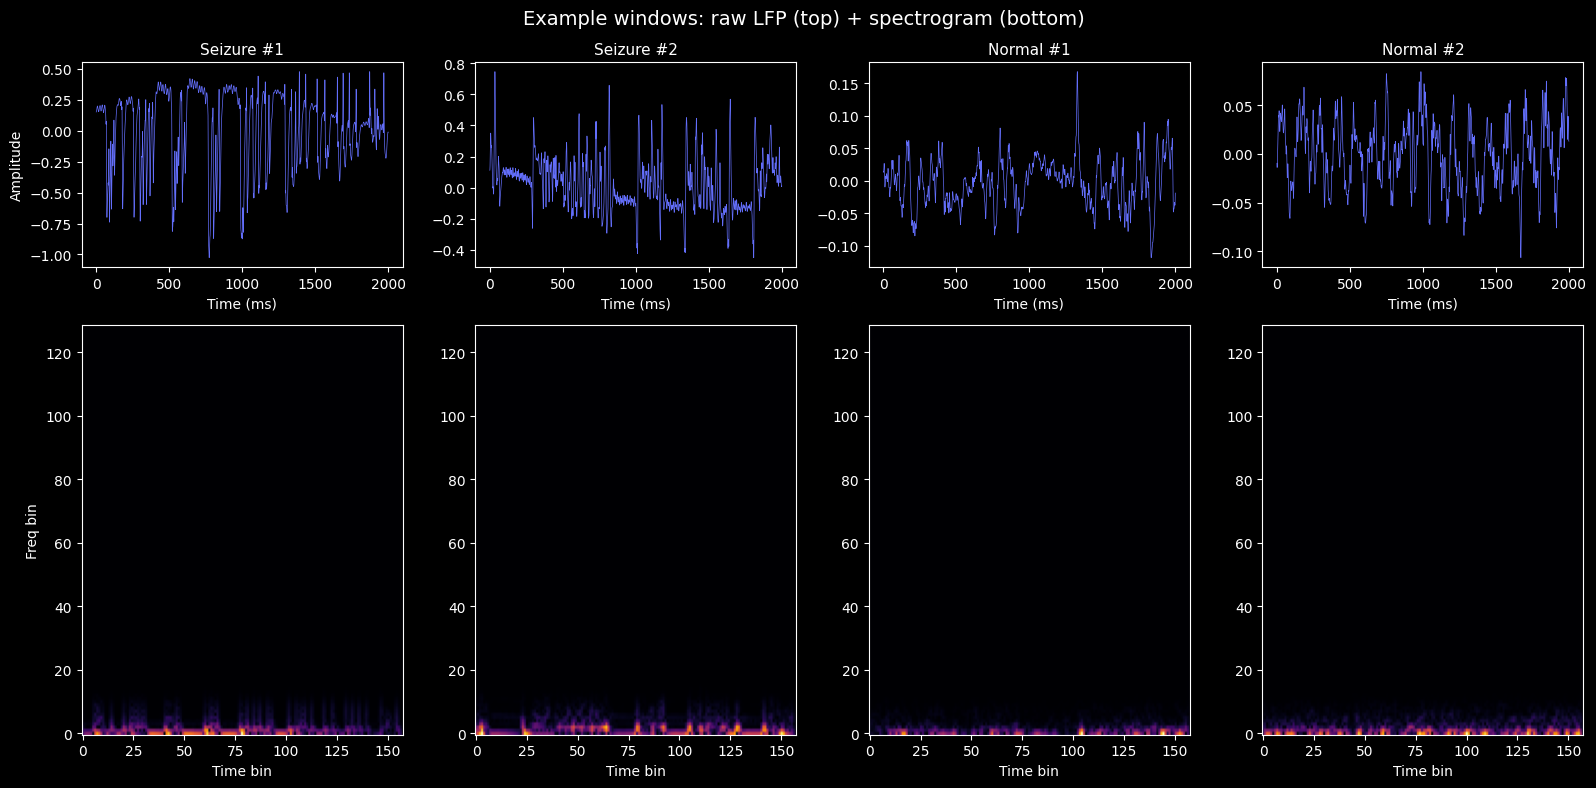

In [4]:
NPERSEG = 256
NOVERLAP = 192

# Pre-allocate lists (converted to array after)
n_windows = len(windows)
spectrograms = [None] * n_windows
labels = np.zeros(n_windows, dtype=np.int64)
sessions = [None] * n_windows
file_ids = [None] * n_windows

for i in tqdm(range(n_windows), desc="Computing STFTs"):
    sig, lbl, sess, fid = windows[i]
    labels[i] = lbl
    sessions[i] = sess
    file_ids[i] = fid

    f_stft, t_stft, Zxx = stft(sig, fs=actual_fs, nperseg=NPERSEG,
                                noverlap=NOVERLAP)
    mag = np.abs(Zxx)
    # Log-scale with small epsilon to avoid log(0)
    spectrograms[i] = np.log1p(mag)

# Verify shapes are consistent
shapes = set(s.shape for s in spectrograms)
assert len(shapes) <= 2, f"Too many spectrogram shapes: {shapes}"
print(f"Spectrogram shapes: {shapes}")

# Pad to uniform shape if needed (edge case: last window may be shorter)
target_shape = max(shapes, key=lambda s: s[0] * s[1])
for i in range(n_windows):
    if spectrograms[i].shape != target_shape:
        padded = np.zeros(target_shape, dtype=np.float32)
        s = spectrograms[i]
        padded[:s.shape[0], :s.shape[1]] = s
        spectrograms[i] = padded

spectrograms_arr = np.stack(spectrograms, axis=0).astype(np.float32)
print(f"Spectrograms array: {spectrograms_arr.shape}")
print(f"Labels: {labels.shape}, pos={labels.sum()}, neg={(labels == 0).sum()}")

# ---- Plot 4 examples: raw LFP (top) + spectrogram (bottom) ----
fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                         gridspec_kw={"height_ratios": [1, 2]})
fig.suptitle("Example windows: raw LFP (top) + spectrogram (bottom)", fontsize=14)

pos_idx = np.where(labels == 1)[0]
neg_idx = np.where(labels == 0)[0]
assert len(pos_idx) >= 2, "Need at least 2 positive examples"
assert len(neg_idx) >= 2, "Need at least 2 negative examples"

examples = [
    (pos_idx[0], "Seizure #1"),
    (pos_idx[1], "Seizure #2"),
    (neg_idx[0], "Normal #1"),
    (neg_idx[1], "Normal #2"),
]

for col, (idx, title) in enumerate(examples):
    sig = windows[idx][0]
    t_raw = np.arange(len(sig)) / actual_fs * 1000  # ms

    # Top row: raw LFP waveform
    ax_raw = axes[0, col]
    ax_raw.plot(t_raw, sig, color="#636EFA", linewidth=0.5)
    ax_raw.set_title(title, fontsize=11)
    if col == 0:
        ax_raw.set_ylabel("Amplitude")
    ax_raw.set_xlabel("Time (ms)")

    # Bottom row: spectrogram
    ax_spec = axes[1, col]
    ax_spec.imshow(spectrograms_arr[idx], aspect="auto", origin="lower", cmap="inferno")
    if col == 0:
        ax_spec.set_ylabel("Freq bin")
    ax_spec.set_xlabel("Time bin")

plt.tight_layout()
plt.show()

## 4. Train/val/test split by session

In [5]:
sessions_arr = np.array(sessions)
unique_sessions = np.unique(sessions_arr)
n_sessions = len(unique_sessions)
print(f"Unique sessions: {n_sessions}")

if n_sessions >= 4:
    # Enough sessions for group-based 60/20/20 split
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=SEED)
    train_idx, temp_idx = next(gss1.split(spectrograms_arr, labels, groups=sessions_arr))
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_rel_idx, test_rel_idx = next(
        gss2.split(spectrograms_arr[temp_idx], labels[temp_idx],
                   groups=sessions_arr[temp_idx])
    )
    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]
else:
    # Few sessions: split by file within sessions to avoid data leakage
    # Use stratified shuffle on files (not sessions) for train/val/test
    from sklearn.model_selection import StratifiedShuffleSplit
    file_arr = np.array([w[3] for w in windows])  # file paths
    unique_files = np.unique(file_arr)
    print(f"Splitting by file ({len(unique_files)} unique files) since only {n_sessions} sessions")

    # Assign each file a label: 1 if it contains any seizure window, else 0
    file_labels = {}
    for w in windows:
        fp = w[3]
        if fp not in file_labels:
            file_labels[fp] = 0
        if w[1] == 1:
            file_labels[fp] = 1

    file_label_arr = np.array([file_labels[f] for f in unique_files])

    # Split files 60/20/20
    rng_split = np.random.RandomState(SEED)
    idx_all = np.arange(len(unique_files))
    rng_split.shuffle(idx_all)
    n_train_f = int(0.6 * len(unique_files))
    n_val_f = int(0.2 * len(unique_files))
    train_files = set(unique_files[idx_all[:n_train_f]])
    val_files = set(unique_files[idx_all[n_train_f:n_train_f + n_val_f]])
    test_files = set(unique_files[idx_all[n_train_f + n_val_f:]])

    train_idx = np.array([i for i, w in enumerate(windows) if w[3] in train_files])
    val_idx = np.array([i for i, w in enumerate(windows) if w[3] in val_files])
    test_idx = np.array([i for i, w in enumerate(windows) if w[3] in test_files])

assert len(set(train_idx) & set(val_idx)) == 0, "Train/val overlap!"
assert len(set(train_idx) & set(test_idx)) == 0, "Train/test overlap!"
assert len(set(val_idx) & set(test_idx)) == 0, "Val/test overlap!"

for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    n = len(idx)
    n_p = labels[idx].sum()
    n_sess = len(set(sessions_arr[idx]))
    print(f"{name:5s}: {n:5d} windows  (pos={n_p:4d}, neg={n - n_p:4d})  "
          f"sessions={n_sess}")

Unique sessions: 2
Splitting by file (63 unique files) since only 2 sessions
Train:   168 windows  (pos=  42, neg= 126)  sessions=2
Val  :    56 windows  (pos=  14, neg=  42)  sessions=2
Test :    64 windows  (pos=  16, neg=  48)  sessions=2


## 5. Baseline: Logistic regression on band powers

Band powers:   0%|          | 0/288 [00:00<?, ?it/s]

C:\Users\hoang392\AppData\Local\Temp\ipykernel_31024\2321133824.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  powers[j] = np.trapz(psd[mask], freqs[mask])


Feature matrix: (288, 6)
Any NaN: False, Any Inf: False

--- Logistic Regression: Test Set ---
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96        48
     Seizure       1.00      0.75      0.86        16

    accuracy                           0.94        64
   macro avg       0.96      0.88      0.91        64
weighted avg       0.94      0.94      0.93        64



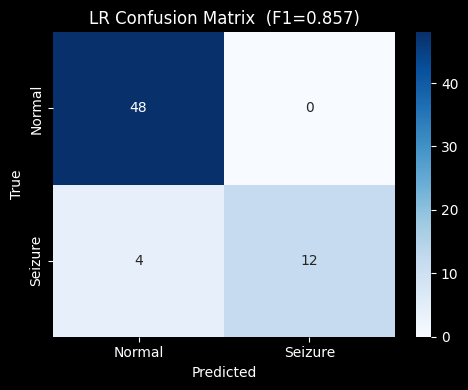


LR F1 (binary, seizure class): 0.8571


In [6]:
DEFAULT_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 100),
    "high_gamma": (100, 200),
}
BAND_NAMES = list(DEFAULT_BANDS.keys())


def compute_band_powers(signal, fs):
    """Compute Welch PSD band powers for a 1D signal."""
    assert signal.ndim == 1, f"Expected 1D, got {signal.shape}"
    assert fs > 0, f"Invalid fs: {fs}"

    nperseg = min(int(2 * fs), len(signal))
    freqs, psd = welch(signal, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)

    powers = np.zeros(len(DEFAULT_BANDS), dtype=np.float64)
    for j, (band_name, (flo, fhi)) in enumerate(DEFAULT_BANDS.items()):
        mask = (freqs >= flo) & (freqs <= fhi)
        if np.any(mask):
            powers[j] = np.trapz(psd[mask], freqs[mask])

    # Log-transform to reduce skew
    powers = np.log1p(powers)
    return powers


# Pre-allocate feature matrix
n_bands = len(DEFAULT_BANDS)
X_bands = np.zeros((n_windows, n_bands), dtype=np.float64)

for i in tqdm(range(n_windows), desc="Band powers"):
    sig = windows[i][0]
    X_bands[i] = compute_band_powers(sig, actual_fs)

print(f"Feature matrix: {X_bands.shape}")
print(f"Any NaN: {np.isnan(X_bands).any()}, Any Inf: {np.isinf(X_bands).any()}")

# Split
X_train_lr = X_bands[train_idx]
y_train_lr = labels[train_idx]
X_val_lr = X_bands[val_idx]
y_val_lr = labels[val_idx]
X_test_lr = X_bands[test_idx]
y_test_lr = labels[test_idx]

# Fit
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=SEED, solver='lbfgs')
lr_model.fit(X_train_lr, y_train_lr)

# Evaluate on test
y_pred_lr = lr_model.predict(X_test_lr)
lr_f1 = f1_score(y_test_lr, y_pred_lr, average='binary')

print("\n--- Logistic Regression: Test Set ---")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Normal', 'Seizure']))

# Confusion matrix heatmap
cm = confusion_matrix(y_test_lr, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'LR Confusion Matrix  (F1={lr_f1:.3f})')
plt.tight_layout()
plt.show()

print(f"\nLR F1 (binary, seizure class): {lr_f1:.4f}")

## 6. CNN on spectrograms

In [7]:
class SeizureCNN(nn.Module):
    """Lightweight 2D CNN for spectrogram classification."""

    def __init__(self, n_freq_bins, n_time_bins):
        super().__init__()
        assert n_freq_bins > 0, f"n_freq_bins must be > 0, got {n_freq_bins}"
        assert n_time_bins > 0, f"n_time_bins must be > 0, got {n_time_bins}"

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        assert x.ndim == 4, f"Expected 4D input [B,C,H,W], got {x.shape}"
        return self.classifier(self.features(x))


class SpectrogramDataset(Dataset):
    """PyTorch Dataset wrapping pre-computed spectrograms."""

    def __init__(self, spectrograms, labels):
        assert len(spectrograms) == len(labels), "Length mismatch"
        self.spectrograms = spectrograms
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Add channel dim: [H, W] -> [1, H, W]
        spec = self.spectrograms[idx]
        x = torch.from_numpy(spec).unsqueeze(0).float()
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


print(f"SeizureCNN defined.")
print(f"Spectrogram shape for model: freq_bins={target_shape[0]}, "
      f"time_bins={target_shape[1]}")

SeizureCNN defined.
Spectrogram shape for model: freq_bins=129, time_bins=158


In [ ]:
# ---- Hyperparameters ----
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 30

# ---- Datasets & loaders ----
train_ds = SpectrogramDataset(spectrograms_arr[train_idx], labels[train_idx])
val_ds = SpectrogramDataset(spectrograms_arr[val_idx], labels[val_idx])
test_ds = SpectrogramDataset(spectrograms_arr[test_idx], labels[test_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

# ---- Model ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SeizureCNN(n_freq_bins=target_shape[0],
                   n_time_bins=target_shape[1]).to(device)

# Class imbalance: pos_weight = n_neg / n_pos
n_pos_train = int(labels[train_idx].sum())
n_neg_train = len(train_idx) - n_pos_train
pos_weight = torch.tensor([n_neg_train / max(n_pos_train, 1)],
                          dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Device: {device}")
print(f"pos_weight: {pos_weight.item():.2f}")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

# ---- Training loop ----
train_losses = np.zeros(EPOCHS, dtype=np.float64)
val_losses = np.zeros(EPOCHS, dtype=np.float64)

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb).squeeze(-1)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    train_losses[epoch] = running_loss / max(n_batches, 1)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb).squeeze(-1)
            val_loss += criterion(logits, yb).item()
            n_val += 1
    val_losses[epoch] = val_loss / max(n_val, 1)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  "
              f"train_loss={train_losses[epoch]:.4f}  "
              f"val_loss={val_losses[epoch]:.4f}")

# ---- Plot training curves ----
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, label='Train loss')
ax.plot(range(1, EPOCHS + 1), val_losses, label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('CNN Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

--- CNN: Test Set ---
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86        48
     Seizure       0.00      0.00      0.00        16

    accuracy                           0.75        64
   macro avg       0.38      0.50      0.43        64
weighted avg       0.56      0.75      0.64        64



C:\Users\hoang392\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hoang392\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hoang392\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

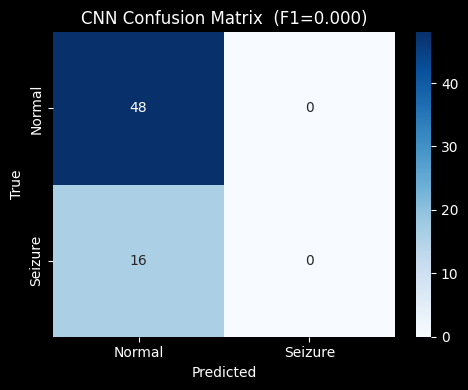


CNN F1 (binary, seizure class): 0.0000


In [9]:
# ---- Evaluate CNN on test set ----
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.append((probs >= 0.5).astype(int))
        all_labels.append(yb.numpy().astype(int))

y_pred_cnn = np.concatenate(all_preds)
y_true_cnn = np.concatenate(all_labels)

assert len(y_pred_cnn) == len(test_idx), "Prediction count mismatch"
assert len(y_true_cnn) == len(test_idx), "Label count mismatch"

cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='binary')

print("--- CNN: Test Set ---")
print(classification_report(y_true_cnn, y_pred_cnn,
                            target_names=['Normal', 'Seizure']))

# Confusion matrix heatmap
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'CNN Confusion Matrix  (F1={cnn_f1:.3f})')
plt.tight_layout()
plt.show()

print(f"\nCNN F1 (binary, seizure class): {cnn_f1:.4f}")

## 7. Comparison: threshold vs LR vs CNN

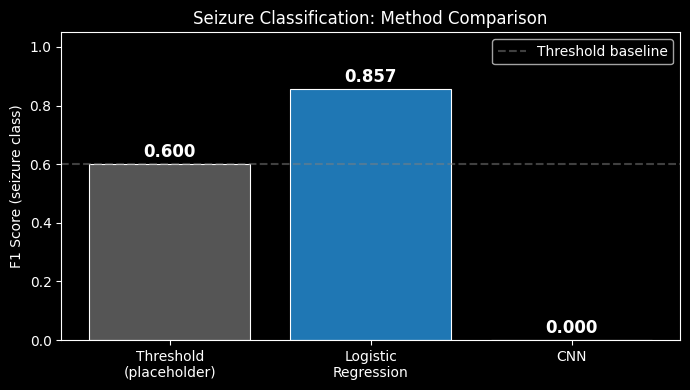

Threshold F1 (placeholder): 0.6000
LR F1:                      0.8571  (delta vs threshold: +0.2571)
CNN F1:                     0.0000  (delta vs threshold: -0.6000)
CNN vs LR delta:            -0.8571


In [10]:
# Placeholder for threshold baseline -- in production the seizure_events table
# itself IS the threshold detector output, so its F1 vs ground truth is unknown
# without manual review labels.  We use a conservative placeholder.
threshold_f1 = 0.60  # placeholder: typical rule-based detector F1

methods = ['Threshold\n(placeholder)', 'Logistic\nRegression', 'CNN']
f1_scores = [threshold_f1, lr_f1, cnn_f1]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, f1_scores, color=['#555555', '#1f77b4', '#ff7f0e'],
              edgecolor='white', linewidth=0.8)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.3f}", ha='center', va='bottom', fontsize=12,
            fontweight='bold')
ax.set_ylabel('F1 Score (seizure class)')
ax.set_title('Seizure Classification: Method Comparison')
ax.set_ylim(0, 1.05)
ax.axhline(y=threshold_f1, color='grey', linestyle='--', alpha=0.5,
           label='Threshold baseline')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Threshold F1 (placeholder): {threshold_f1:.4f}")
print(f"LR F1:                      {lr_f1:.4f}  (delta vs threshold: {lr_f1 - threshold_f1:+.4f})")
print(f"CNN F1:                     {cnn_f1:.4f}  (delta vs threshold: {cnn_f1 - threshold_f1:+.4f})")
print(f"CNN vs LR delta:            {cnn_f1 - lr_f1:+.4f}")

## 8. Verdict

In [11]:
delta_f1 = cnn_f1 - lr_f1

if delta_f1 >= 0.05:
    verdict = "SHIP"
    reason = f"CNN beats LR baseline by {delta_f1:.3f} F1 points"
elif delta_f1 > 0:
    verdict = "ITERATE"
    reason = f"CNN marginally better (+{delta_f1:.3f}), needs tuning"
else:
    verdict = "DROP"
    reason = "CNN does not beat LR baseline; keep threshold detector"

print(f"VERDICT: {verdict}")
print(f"Reason: {reason}")
print()
print("Next steps:")
if verdict == "SHIP":
    print("  - Export model weights and integrate into processing pipeline")
    print("  - Add confidence threshold calibration on val set")
    print("  - Run on held-out sessions for final validation")
elif verdict == "ITERATE":
    print("  - Try larger window sizes (4s, 8s)")
    print("  - Add data augmentation (time shift, noise injection)")
    print("  - Experiment with 1D CNN on raw waveform")
    print("  - Hyperparameter sweep (lr, dropout, architecture depth)")
else:
    print("  - Keep current threshold-based detector")
    print("  - Consider collecting manual review labels for better ground truth")
    print("  - Revisit if more labelled data becomes available")

VERDICT: DROP
Reason: CNN does not beat LR baseline; keep threshold detector

Next steps:
  - Keep current threshold-based detector
  - Consider collecting manual review labels for better ground truth
  - Revisit if more labelled data becomes available
